In [1]:
import polars as pl
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = '../data'
output_dir = '../data/processed'

### Загрузка датасетов

In [2]:
apps_df = pl.read_csv(
    os.path.join(data_dir, 'applications.csv'),
    ignore_errors=True
)

print(apps_df.shape)
apps_df.head(3)

(239664, 30)


appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
i64,str,str,bool,str,i64,str,str,str,str,f64,f64,bool,bool,bool,f64,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str
10,"""Counter-Strike""","""game""",false,"""2000-11-01""",0,"""Play the world's number 1 onli…","""English<strong>*</strong>, Fre…","""https://shared.akamai.steamsta…","""https://store.akamai.steamstat…",88.0,161854.0,true,true,true,999.0,999.0,0.0,"""USD""",null,null,null,null,null,null,null,null,null,"""2025-09-07 16:27:12.218587+00:…","""2025-09-29 02:01:37.107239+00:…"
20,"""Team Fortress Classic""","""game""",false,"""1999-04-01""",0,"""One of the most popular online…","""English, French, German, Itali…","""https://shared.akamai.steamsta…","""https://store.akamai.steamstat…",null,6633.0,true,true,true,499.0,499.0,0.0,"""USD""",null,null,null,null,null,null,null,null,null,"""2025-09-07 16:27:12.218587+00:…","""2025-09-29 02:01:37.107239+00:…"
30,"""Day of Defeat""","""game""",false,"""2003-05-01""",0,"""Enlist in an intense brand of …","""English, French, German, Itali…","""https://shared.akamai.steamsta…","""https://store.akamai.steamstat…",79.0,4308.0,true,true,true,499.0,499.0,0.0,"""USD""",null,null,null,null,null,null,null,null,null,"""2025-09-07 16:27:12.218587+00:…","""2025-09-29 02:01:37.107239+00:…"


In [4]:
genres_df = pl.read_csv(os.path.join(data_dir, 'genres.csv'))
app_genres_df = pl.read_csv(os.path.join(data_dir, 'application_genres.csv'))

cats_df = pl.read_csv(os.path.join(data_dir, 'categories.csv'))
app_cats_df = pl.read_csv(os.path.join(data_dir, 'application_categories.csv'))

print(genres_df)
print(app_genres_df)
print(cats_df)
print(app_cats_df)

shape: (154, 2)
┌─────┬────────────────────────────┐
│ id  ┆ name                       │
│ --- ┆ ---                        │
│ i64 ┆ str                        │
╞═════╪════════════════════════════╡
│ 1   ┆ Aventură                   │
│ 2   ┆ Многопользовательские игры │
│ 3   ┆ Nezávislé                  │
│ 4   ┆ Strategie                  │
│ 5   ┆ Strategy                   │
│ …   ┆ …                          │
│ 150 ┆ 冒险                       │
│ 151 ┆ Short                      │
│ 154 ┆ إثارة                      │
│ 160 ┆ Akció                      │
│ 167 ┆ مجانية                     │
└─────┴────────────────────────────┘
shape: (587_515, 2)
┌─────────┬──────────┐
│ appid   ┆ genre_id │
│ ---     ┆ ---      │
│ i64     ┆ i64      │
╞═════════╪══════════╡
│ 10      ┆ 122      │
│ 20      ┆ 122      │
│ 30      ┆ 122      │
│ 40      ┆ 122      │
│ 50      ┆ 122      │
│ …       ┆ …        │
│ 3992900 ┆ 113      │
│ 3992900 ┆ 122      │
│ 3992900 ┆ 144      │
│ 3996190 ┆ 31 

Можно заметить, что жанр/категория может повторяться в датасете несколько раз на разных языках. Возможно, это связано с особенностями парсинга страниц при сборе данных. Нам необходимо оставить жанры/категории только на одном языке (английском). Воспользуемся библиотекой `deep-translator`.

### Перевод жанров и категорий на английский язык

In [5]:
from deep_translator import GoogleTranslator

def translate_names(names_list: list[str], translator) -> list[str]:
    translated = []
    for name in tqdm(names_list):
        translated.append(translator.translate(name).strip().lower())

    return translated

translator = GoogleTranslator(source='auto', target='en')

genres_translated = genres_df.with_columns(name_en = pl.Series(translate_names(genres_df['name'].to_list(), translator)))
genres_translated

100%|██████████| 154/154 [00:59<00:00,  2.60it/s]


id,name,name_en
i64,str,str
1,"""Aventură""","""venture"""
2,"""Многопользовательские игры""","""multiplayer games"""
3,"""Nezávislé""","""independently"""
4,"""Strategie""","""strategy"""
5,"""Strategy""","""strategy"""
…,…,…
150,"""冒险""","""adventure"""
151,"""Short""","""short"""
154,"""إثارة""","""stir"""


In [6]:
print('Уникальных жанров после перевода на английский язык:', genres_translated['name_en'].n_unique())
genres_translated['name_en'].unique().to_list()

Уникальных жанров после перевода на английский язык: 75


['accounting',
 'independent producer',
 'independent',
 'design & illustration',
 'casual games',
 'early access',
 'ryo',
 'mmo',
 'strategy',
 'animation & modeling',
 'venture',
 'leisure',
 '冒險',
 'sport',
 'racing',
 'multiplayer games',
 'noncommittal',
 'action',
 'nudity',
 'role play',
 '獨立製作',
 'aventura',
 'audio production',
 'pastime',
 'independently',
 '動作',
 'game development',
 'utilities',
 'adventure',
 'casual',
 'video production',
 'physical education',
 'web-publishing',
 'simulations',
 '360 video',
 'rpg',
 'tutorial',
 'photo editing',
 'web publishing',
 'independents',
 'adventurous',
 'share',
 'violent',
 'sexual content',
 'role-playing games',
 'simulation',
 'role',
 'massive multiplayer',
 'recreational',
 'short',
 'racing games',
 '休閒',
 'adventure games',
 'adventures',
 'free',
 'corse',
 'movie',
 'documentary',
 'strategic',
 'strategies',
 'gore',
 'race',
 'stir',
 'massively multiplayer',
 'software training',
 'episodic',
 'a simulation',
 '

После перевода один и тот же жанр все равно может быть написан по-разному. Поэтому для того, чтобы точно оставить только уникальные жанры, самым надежным способом будет написать ручной словарь приведения к базовым жанрам (То же самое сделаем позднее для категорий)

In [7]:
GENRE_GROUPS = {
    'indie': ['independents', 'independent', 'independent producer', 'independently', 'india', '獨立製作'],
    'action': ['動作', 'stir'],
    'strategy': ['strategies', 'strategic'],
    'adventure': ['adventures', 'adventure games', 'adventurous', 'aventura', 'venture', '冒險'],
    'simulation': ['simulations', 'simulators', 'a simulation'],
    'rpg': ['role-playing games', 'role playing games', 'role play', 'role', 'ryo'],
    'casual': ['casual games', '休閒', 'leisure', 'pastime', 'noncommittal', 'recreational'],
    'sports': ['sport', 'physical education'],
    'racing': ['racing games', 'race', 'corse'],
    'massively multiplayer': ['massive multiplayer', 'multiplayer games', 'mmo'],
    'free to play': ['free']
}

GENRE_MAP = {
    alias: target 
    for target, aliases in GENRE_GROUPS.items() 
    for alias in aliases
}

genres_translated = genres_translated.with_columns(
    name_clean = pl.col('name_en').replace(GENRE_MAP)
)

print('Чистых жанров осталось:', genres_translated['name_clean'].n_unique())

Чистых жанров осталось: 36


In [8]:
cats_translated = cats_df.with_columns(name_en = pl.Series(translate_names(cats_df['name'].to_list(), translator)))
cats_translated

100%|██████████| 462/462 [03:06<00:00,  2.48it/s]


id,name,name_en
i64,str,str
1,"""Remote Play en móvil""","""remote play on mobile"""
2,"""Flera spelare""","""multiple players"""
3,"""Tablette Remote Play""","""tablette remote play"""
4,"""Multiplayer""","""multiplayer"""
5,"""Таблицы лидеров Steam""","""steam leaderboards"""
…,…,…
519,"""ورشة Steam""","""steam workshop"""
528,"""الإحصاءات""","""statistics"""
530,"""Többjátékos""","""multiplayer"""


In [9]:
print('Уникальных категорий после перевода на английский язык:', cats_translated['name_en'].n_unique())
cats_translated['name_en'].unique().to_list()

Уникальных категорий после перевода на английский язык: 250


['for multiple players',
 'color alternatives',
 'remote play pe telefon',
 'single',
 'includes level editor',
 'custom volume controls',
 'valve anti cheat enabled',
 'co-op online',
 'level editor included',
 'non-cellular remote play',
 'steam game cards',
 'tablette remote play',
 '線上玩家對戰',
 'vr compatibility',
 'steam performances',
 'multiplayer',
 'workshop on steam',
 'save anytime',
 'valve anti-cheat enabled',
 'jxj',
 'pvp split/shared screen.',
 'add. content',
 'co-op/split-screen pvp',
 'pvp in lan',
 'stereo-sound',
 'group play',
 'comment available',
 'shared/split screen pvp',
 'adjustable difficulty level',
 'remote play auf tablets',
 'steam achievements',
 'remote play together',
 'full support for controllers',
 'lan pair',
 'partial support for controls',
 '線上合作',
 'independent volume controls',
 'stereo sound',
 'multipemain',
 'player vs player (online)',
 'closed captions',
 'adjustable difficulty',
 'vr only',
 'single player mode',
 'som surround',
 'playab

In [10]:
CAT_GROUPS = {
    # Режимы игры
    'single-player': [
        'single player game', 'single player mode', 'single', 'a player', '單人', 'solo game', 'single player'
    ],
    'multiplayer': [
        'multiplayer mode', 'multiplayer', 'for multiple players', 'multiple people', 'multiplayer game', 
        'multipemain', 'multiple players', 'cross-platform multiplayer game', 'platform independent multiplayer'
    ],
    'co-op': [
        'cooperate', 'cooperative', 'online cooperation', 'collaboration online', 'cooperative game', 
        '線上合作', 'co-op online', 'online co-op', 'online pair', 'coop online', 'cooperativ online', 
        'online cooperative', 'cooperative gra', 'coop. the (with)departure screen'
    ],
    'pvp': [
        'pvp online', 'online-pvp', 'player vs player online', 'player vs player (online)', 
        'player versus player', 'jxj', 'online pvp', 'jxj on-line', 'player vs player', 
        'player vs player (lan)', 'pvp on local area network (lan)', 'lan pvp', 'lan-pvp', 'pvp in lan',
        'player vs player on local network', 'local split-screen pvp', 'split-screen pvp games', 
        'shared/split pvp screen', 'split-screen pvp'
    ],
    'lan co-op': [
        'lan co-op', 'co-op lan', 'coop on lan', 'cooperative on lan', 'cooperative lan', 'coop. on a local network (lan)'
    ],
    
    # Разделенный экран
    'shared/split screen': [
        'split screen', 'co-op/split screen pvp', '(shared) screen pvp', 'shared/split co-op screen', 
        'co-op (shared/split screen)', 'player vs player (shared/split screen)', 
        'player vs player in shared or split screen', 'split-screen co-op games', 'co-op/split-screen pvp',
        'coop. split/shared screen'
    ],
    
    # Геймпады
    'full controller support': [
        'full support for controls', 'full driver support', 'full game controller support', 
        'full support for controllers', 'compat. total control', 'compat. total with command', 'full controller support'
    ],
    'partial controller support': [
        'compat. partial with control', 'compat. partial controllers', 'partial support for controllers', 
        'partial support for controls', 'partial support for control', 'partial controller support'
    ],
    
    # Фичи Steam
    'steam cloud': ['steam cloud', 'steam 雲端'],
    'steam achievements': ['achievementy', 'steam achievement', 'steam achievements', 'proezas steam'],
    'steam trading cards': ['trading cards', 'steam game cards', 'trading cards in steam', 'steam trading card', 'steam trading cards'],
    'steam leaderboards': ['steam ranking lists', 'steam top charts', 'steam leaderboards', 'steam rankings', 'steam charts'],
    'steam workshop': ['steam office', 'steam workshop', 'workshop on steam'],
    'stats': ['stats', 'statistics', '統計'],
    'remote play together': ['remote play together', 'remote\xa0play\xa0together'],
    
    # Remote Play
    'remote play on mobile': [
        'remote play on mobile', 'remote play on your phone', 'remote play on phone', 'play remotely on your phone', 
        'remote play pe telefon', 'remote play on phones', 'non-cellular remote play'
    ],
    'remote play on tablet': [
        'remote play op tablets', 'remote play auf tablets', 'remote play no tablet', 'remote play on tablet', 
        'tablette remote play', 'play remotely on your tablet'
    ],
    'remote play on tv': ['remote play on tv devices', 'remote\xa0play en tv', 'remote play on tvs'],
    
    # Прочее
    'family sharing': [
        'sharing with family', 'share with family', 'family library', 'family loan', 'home sharing', 
        '親友同享', 'game sharing', 'library sharing', 'perhejako'
    ],
    'includes level editor': [
        'includes a level editor', 'includes section editor', 'contains a level editor', 
        'level editor included', 'contains level editor', 'includes level editing', 'with level editor', 'track editor'
    ],
    'dlc': ['downloadable content', 'additional content', 'dlc', '可下載的內容'],
    'vr': ['vr support', 'vr supported', 'vr only']
}

CAT_MAP = {
    alias: target 
    for target, aliases in CAT_GROUPS.items() 
    for alias in aliases
}

cats_translated = cats_translated.with_columns(
    name_clean = pl.col('name_en').replace(CAT_MAP)
)

print('Чистых категорий осталось:', cats_translated['name_clean'].n_unique())

Чистых категорий осталось: 124


### Объединение таблиц

Так же заметим, что одной игре соответствует несколько категорий и жанров, поэтому перед объединением, создадим столбец со список категорий/жанров для каждой игры

In [11]:
genre_names_df = app_genres_df.join(genres_translated, how='left', left_on='genre_id', right_on='id')
genre_names_df

appid,genre_id,name,name_en,name_clean
i64,i64,str,str,str
10,122,"""Action""","""action""","""action"""
20,122,"""Action""","""action""","""action"""
30,122,"""Action""","""action""","""action"""
40,122,"""Action""","""action""","""action"""
50,122,"""Action""","""action""","""action"""
…,…,…,…,…
3992900,113,"""Adventure""","""adventure""","""adventure"""
3992900,122,"""Action""","""action""","""action"""
3992900,144,"""RPG""","""rpg""","""rpg"""


In [12]:
genre_names_df = genre_names_df.group_by('appid').agg(
    pl.col('name'),
    pl.col('name_en'), 
    pl.col('name_clean')
)

genre_duplicates_df = genre_names_df.filter(
    pl.col('name_clean').list.unique().list.len() <
    pl.col('name_clean').list.len()
)

print('Игр с дубликатами в жанрах:', len(genre_duplicates_df))
genre_duplicates_df.head(10)

Игр с дубликатами в жанрах: 1


appid,name,name_en,name_clean
i64,list[str],list[str],list[str]
34330,"[""Strategy"", ""Estrategia""]","[""strategy"", ""strategy""]","[""strategy"", ""strategy""]"


In [13]:
cat_names_df = app_cats_df.join(cats_translated, left_on='category_id', right_on='id', how='left')

cat_names_df = cat_names_df.group_by('appid').agg(
    pl.col('name_en'),
    pl.col('name_clean')
)

cat_duplicates_df = cat_names_df.filter(
    pl.col('name_clean').list.unique().list.len() < 
    pl.col('name_clean').list.len()
)

print('Игр с дубликатами в категориях:', len(cat_duplicates_df))
cat_duplicates_df.head(10)

Игр с дубликатами в категориях: 33088


appid,name_en,name_clean
i64,list[str],list[str]
3520880,"[""cross-platform multiplayer"", ""family sharing"", … ""online co-op""]","[""cross-platform multiplayer"", ""family sharing"", … ""co-op""]"
1304600,"[""steam achievements"", ""full controller support"", … ""online co-op""]","[""steam achievements"", ""full controller support"", … ""co-op""]"
2496330,"[""full controller support"", ""multi-player"", … ""online co-op""]","[""full controller support"", ""multi-player"", … ""co-op""]"
3347170,"[""steam achievements"", ""family sharing"", … ""online co-op""]","[""steam achievements"", ""family sharing"", … ""co-op""]"
1621660,"[""steam achievements"", ""full controller support"", … ""shared/split screen pvp""]","[""steam achievements"", ""full controller support"", … ""shared/split screen pvp""]"
3634410,"[""family sharing"", ""multi-player"", … ""online co-op""]","[""family sharing"", ""multi-player"", … ""co-op""]"
2671040,"[""steam trading cards"", ""steam achievements"", … ""family sharing""]","[""steam trading cards"", ""steam achievements"", … ""family sharing""]"
1179655,"[""steam achievements"", ""full controller support"", … ""shared/split screen pvp""]","[""steam achievements"", ""full controller support"", … ""shared/split screen pvp""]"
1233740,"[""pvp"", ""in-app purchases"", … ""online co-op""]","[""pvp"", ""in-app purchases"", … ""co-op""]"


In [14]:
apps_full_df = (
    apps_df
        .join(
            cat_names_df
                .with_columns(category = pl.col('name_clean').list.unique())
                .select(['appid', 'category']), 
            on='appid', 
            how='left'
        ).join(
            genre_names_df
                .with_columns(genre = pl.col('name_clean').list.unique())
                .select(['appid', 'genre']), 
            on='appid', 
            how='left'
        )
)

print(apps_full_df.shape)
apps_full_df.head(3)

(239664, 32)


appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at,category,genre
i64,str,str,bool,str,i64,str,str,str,str,f64,f64,bool,bool,bool,f64,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,list[str],list[str]
10,"""Counter-Strike""","""game""",false,"""2000-11-01""",0,"""Play the world's number 1 onli…","""English<strong>*</strong>, Fre…","""https://shared.akamai.steamsta…","""https://store.akamai.steamstat…",88.0,161854.0,true,true,true,999.0,999.0,0.0,"""USD""",null,null,null,null,null,null,null,null,null,"""2025-09-07 16:27:12.218587+00:…","""2025-09-29 02:01:37.107239+00:…","[""color alternatives"", ""pvp"", … ""shared/split screen pvp""]","[""action""]"
20,"""Team Fortress Classic""","""game""",false,"""1999-04-01""",0,"""One of the most popular online…","""English, French, German, Itali…","""https://shared.akamai.steamsta…","""https://store.akamai.steamstat…",null,6633.0,true,true,true,499.0,499.0,0.0,"""USD""",null,null,null,null,null,null,null,null,null,"""2025-09-07 16:27:12.218587+00:…","""2025-09-29 02:01:37.107239+00:…","[""pvp"", ""family sharing"", … ""shared/split screen pvp""]","[""action""]"
30,"""Day of Defeat""","""game""",false,"""2003-05-01""",0,"""Enlist in an intense brand of …","""English, French, German, Itali…","""https://shared.akamai.steamsta…","""https://store.akamai.steamstat…",79.0,4308.0,true,true,true,499.0,499.0,0.0,"""USD""",null,null,null,null,null,null,null,null,null,"""2025-09-07 16:27:12.218587+00:…","""2025-09-29 02:01:37.107239+00:…","[""color alternatives"", ""family sharing"", … ""valve anti-cheat enabled""]","[""action""]"


### EDA и подготовка данных для моделей

In [146]:
final_cols = [
    'appid', 'name', 'type', 'is_free', 'release_date',
    'metacritic_score', 'recommendations_total', 
    'mat_achievement_count', 'mat_currency', 'mat_initial_price', 
    'mat_final_price', 'mat_discount_percent', 'mat_supports_windows', 
    'mat_supports_mac', 'mat_supports_linux',
    'genre', 'category', 'short_description'
]

apps_clean = apps_full_df.select(final_cols)

apps_clean.head(3)

appid,name,type,is_free,release_date,metacritic_score,recommendations_total,mat_achievement_count,mat_currency,mat_initial_price,mat_final_price,mat_discount_percent,mat_supports_windows,mat_supports_mac,mat_supports_linux,genre,category,short_description
i64,str,str,bool,str,f64,f64,f64,str,f64,f64,f64,bool,bool,bool,list[str],list[str],str
10,"""Counter-Strike""","""game""",false,"""2000-11-01""",88.0,161854.0,null,"""USD""",999.0,999.0,0.0,true,true,true,"[""action""]","[""color alternatives"", ""pvp"", … ""shared/split screen pvp""]","""Play the world's number 1 onli…"
20,"""Team Fortress Classic""","""game""",false,"""1999-04-01""",null,6633.0,null,"""USD""",499.0,499.0,0.0,true,true,true,"[""action""]","[""pvp"", ""family sharing"", … ""shared/split screen pvp""]","""One of the most popular online…"
30,"""Day of Defeat""","""game""",false,"""2003-05-01""",79.0,4308.0,null,"""USD""",499.0,499.0,0.0,true,true,true,"[""action""]","[""color alternatives"", ""family sharing"", … ""valve anti-cheat enabled""]","""Enlist in an intense brand of …"


In [147]:
apps_clean['type'].value_counts()

type,count
str,u32
"""music""",8713
"""dlc""",53792
"""demo""",23521
"""game""",150279
"""video""",692
null,2667


Отфильтруем по полю type, так как для рекомендательной системы нас интересуют только игры

In [ ]:
apps_clean = apps_clean.filter(pl.col('type') == 'game')
apps_clean.shape

Обработка пропусков:

In [ ]:
apps_clean.null_count()

In [ ]:
apps_clean = apps_clean.with_columns(
    pl.col('metacritic_score').fill_null(0),
    pl.col('recommendations_total').fill_null(0),
    pl.col('category').fill_null([]),
    pl.col('genre').fill_null([]),
    pl.col('mat_achievement_count').fill_null(0),
    pl.col('mat_initial_price').fill_null(0),
    pl.col('mat_final_price').fill_null(0),
    pl.col('mat_discount_percent').fill_null(0),
    pl.col('short_description').fill_null('')
)
apps_clean.null_count()

Создадим создадим поле с объединенной текстовой информацией, для обучения продвинутых моделей с TF-IDF или эмбеддингами 

In [151]:
apps_clean = apps_clean.with_columns(
    release_year = pl.col('release_date').str.slice(0, 4).cast(pl.Int32, strict=False)
).with_columns(
    genres_str = pl.col('genre').list.join(', '),
    categories_str = pl.col('category').list.join(', ')
).with_columns(
    combined_text = (
        pl.col('name') +
        " | Genres: " + pl.col('genres_str') +
        " | Categories: " + pl.col('categories_str') +
        " | " + pl.col('short_description')
    )
).drop(['genres_str', 'categories_str', 'release_date', 'short_description'])

In [152]:
apps_clean.glimpse()

Rows: 150279
Columns: 18
$ appid                       <i64> 10, 20, 30, 40, 50, 60, 70, 80, 130, 220
$ name                        <str> 'Counter-Strike', 'Team Fortress Classic', 'Day of Defeat', 'Deathmatch Classic', 'Half-Life: Opposing Force', 'Ricochet', 'Half-Life', 'Counter-Strike: Condition Zero', 'Half-Life: Blue Shift', 'Half-Life 2'
$ type                        <str> 'game', 'game', 'game', 'game', 'game', 'game', 'game', 'game', 'game', 'game'
$ is_free                    <bool> False, False, False, False, False, False, False, False, False, False
$ metacritic_score            <f64> 88.0, 0.0, 79.0, 0.0, 0.0, 0.0, 96.0, 65.0, 71.0, 96.0
$ recommendations_total       <f64> 161854.0, 6633.0, 4308.0, 2338.0, 22793.0, 4371.0, 107092.0, 20113.0, 16808.0, 184698.0
$ mat_achievement_count       <f64> 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 69.0
$ mat_currency                <str> 'USD', 'USD', 'USD', 'USD', 'USD', 'USD', 'USD', 'USD', 'USD', 'USD'
$ mat_initial_price        

In [153]:
apps_clean.describe()

statistic,appid,name,type,is_free,metacritic_score,recommendations_total,mat_achievement_count,mat_currency,mat_initial_price,mat_final_price,mat_discount_percent,mat_supports_windows,mat_supports_mac,mat_supports_linux,genre,category,release_year,combined_text
str,f64,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",150279.0,"""150279""","""150279""",150279.0,150279.0,150279.0,150279.0,"""90311""",150279.0,150279.0,150279.0,150279.0,150279.0,150279.0,150279.0,150279.0,115796.0,"""150279"""
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,"""59968""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34483.0,"""0"""
"""mean""",2.0808e6,null,null,0.126392,2.043865,687.815124,13.957985,null,12999.683835,11318.665702,3.62173,0.999987,0.998756,0.998636,null,null,2021.453461,null
"""std""",1.0534e6,null,null,null,12.22523,18061.248653,127.649776,null,679562.250767,591884.957157,15.141191,null,null,null,null,null,27.780764,null
"""min""",10.0,""" Ash Survival ""","""game""",0.0,0.0,0.0,0.0,"""AED""",0.0,0.0,0.0,0.0,0.0,0.0,null,null,1969.0,""" Ash Survival | Genres: massi…"
"""25%""",1.19249e6,null,null,null,0.0,0.0,0.0,null,0.0,0.0,0.0,null,null,null,null,null,2019.0,null
"""50%""",2.09239e6,null,null,null,0.0,0.0,0.0,null,199.0,199.0,0.0,null,null,null,null,null,2022.0,null
"""75%""",2.97461e6,null,null,null,0.0,0.0,13.0,null,799.0,699.0,0.0,null,null,null,null,null,2024.0,null
"""max""",3.99087e6,"""𣸩""","""game""",1.0,97.0,4.661011e6,9821.0,"""ZAR""",8.99e7,8.91e7,95.0,1.0,1.0,1.0,null,null,9998.0,"""𣸩 | Genres: indie, casual, adv…"


Сводная статистика `describe()` показывает следующие ключевые особенности и аномалии данных:
1. **Выбросы в годах выпуска:** Минимальный год — 1969 (ошибка нулевого Unix-timestamp), максимальный — 9998 (заглушка Steam API для игр в разработке).
2. **Аномально высокие цены:** Максимальная цена в `mat_initial_price` доходит до 8.99e7 (89 млн), что связано с представлением цен в центах/копейках и наличием цен в редких региональных валютах (VND, IDR, RUB).

#### Выбросы в поле `release_year`

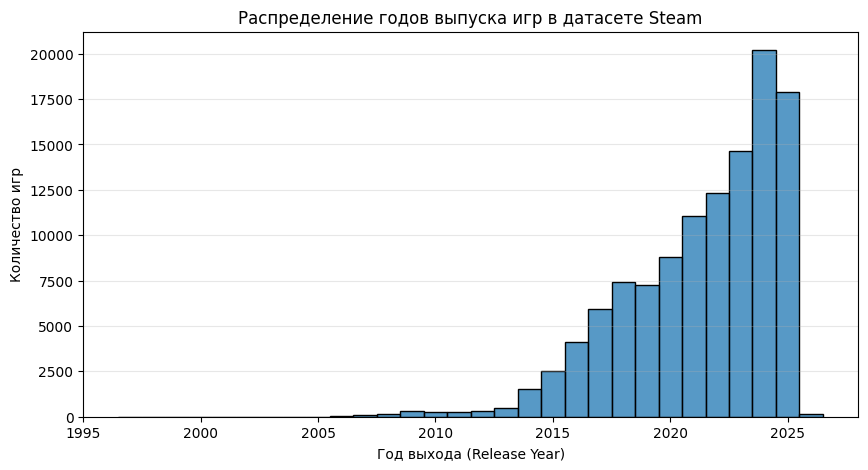

In [154]:
valid_years = apps_clean.filter(
    (pl.col('release_year') >= 1990) & (pl.col('release_year') <= 2026)
)['release_year']

plt.figure(figsize=(10, 5))
sns.histplot(valid_years, discrete=True)
plt.title('Распределение годов выпуска игр в датасете Steam')
plt.xlabel('Год выхода (Release Year)')
plt.ylabel('Количество игр')
plt.grid(axis='y', alpha=0.3)
plt.show()

Большая часть игр вышли недавно - в 2022-2025 годах, но есть также более старые, выпущенные в 2000-х годах. Фильтруем аномалии года выхода в диапазон 1970–2026.

In [155]:
apps_clean = apps_clean.with_columns(
    pl.when(pl.col("release_year").is_between(1970, 2026))
    .then(pl.col("release_year"))
)

In [156]:
apps_clean['release_year'].describe()

statistic,value
str,f64
"""count""",115745.0
"""null_count""",34534.0
"""mean""",2021.335531
"""std""",3.242419
"""min""",1997.0
"""25%""",2019.0
"""50%""",2022.0
"""75%""",2024.0
"""max""",2026.0


#### Выбросы в ценах

Теперь посмотрим распределение цен на игры

In [157]:
quantiles = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]

print("=== Анализ цен платных игр ===")
for q in quantiles:
    val = (apps_clean['mat_initial_price'].quantile(q)) / 100.0
    print(f"Квантиль {q*100:4.1f}%:  ${val:.2f}")

=== Анализ цен платных игр ===
Квантиль 50.0%:  $1.99
Квантиль 75.0%:  $7.99
Квантиль 90.0%:  $14.99
Квантиль 95.0%:  $19.99
Квантиль 99.0%:  $49.99
Квантиль 99.9%:  $630.00


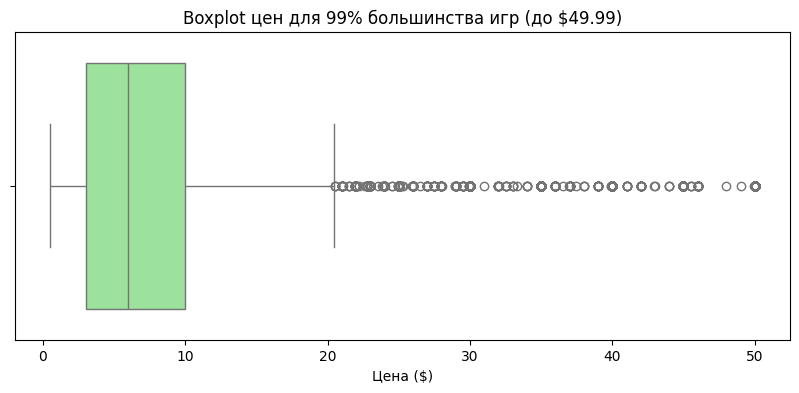

In [158]:
# Находим 99-й перцентиль цены
p99 = (apps_clean['mat_initial_price'] / 100.0).quantile(0.99)

filtered_prices = (
    apps_clean
    .filter((pl.col('mat_initial_price') > 0) & (pl.col('mat_initial_price') / 100.0 <= p99))
    .select((pl.col('mat_initial_price') / 100.0).alias('price_usd'))
    .to_pandas()
)

plt.figure(figsize=(10, 4))
sns.boxplot(x=filtered_prices['price_usd'], color='lightgreen')
plt.title(f'Boxplot цен для 99% большинства игр (до ${p99:.2f})')
plt.xlabel('Цена ($)')
plt.show()

(150, 18)

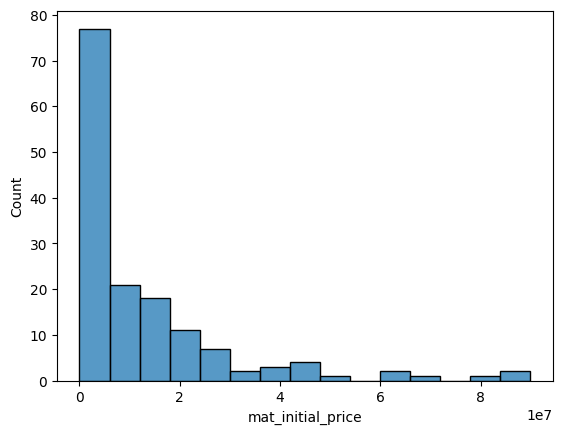

In [159]:
outliers = apps_clean.filter(pl.col('mat_initial_price') > pl.col('mat_initial_price').quantile(0.999))

sns.histplot(x=outliers['mat_initial_price'])
outliers.shape

Далее проверим, связаны ли выбросы в ценах с валютой

In [160]:
apps_clean['mat_currency'].value_counts(sort=True)

mat_currency,count
str,u32
"""USD""",88943
null,59968
"""EUR""",269
"""AUD""",220
"""PLN""",211
…,…
"""SGD""",1
"""ZAR""",1
"""ILS""",1


In [161]:
outliers['mat_currency'].value_counts(sort=True)

mat_currency,count
str,u32
"""VND""",68
"""IDR""",29
"""RUB""",15
"""PHP""",10
"""INR""",9
…,…
"""KRW""",3
"""THB""",1
"""TWD""",1


In [174]:
outliers.filter(pl.col('mat_currency').is_in(['USD', 'EUR'])).select(['mat_currency', 'mat_initial_price', 'mat_final_price'])

mat_currency,mat_initial_price,mat_final_price
str,f64,f64
"""USD""",99900.0,99900.0
"""USD""",99998.0,99998.0
"""USD""",99998.0,99998.0
"""USD""",190000.0,190000.0


Из всех 150 выбросов только 4 записаны в 'USD'. Аномально высокие цены связаны с тем, что они записаны не в USD, а в других региональных валютах (VND, IDR, RUB).

In [187]:
assert apps_clean.filter(pl.col('is_free') & ((pl.col('mat_initial_price') != 0) | pl.col('mat_currency').is_not_null())).height == 0
assert apps_clean.filter((pl.col('mat_initial_price') != 0) & pl.col('mat_currency').is_null()).height == 0

С помощью тестов `assert` мы проверили два ключевых бизнес-инварианта датасета Steam:
1. Бесплатные игры всегда имеют цену 0 и валюту null.
2. Платные игры с ценой всегда имеют заполненную валюту.

In [163]:
print(f'Всего {apps_clean.filter(pl.col("mat_currency") != "USD").height}' 
        ' цен указаны в других валютах (не USD)')

Всего 1368 цен указаны в других валютах (не USD)


In [164]:
apps_clean.filter(pl.col('mat_currency') == 'EUR')['mat_initial_price'].describe()

statistic,value
str,f64
"""count""",269.0
"""null_count""",0.0
"""mean""",977.085502
"""std""",1513.220162
"""min""",79.0
"""25%""",329.0
"""50%""",589.0
"""75%""",999.0
"""max""",19499.0


In [165]:
apps_clean.filter(pl.col('mat_currency') == 'USD')['mat_initial_price'].describe()

statistic,value
str,f64
"""count""",88943.0
"""null_count""",0.0
"""mean""",948.987655
"""std""",1708.810131
"""min""",50.0
"""25%""",299.0
"""50%""",599.0
"""75%""",999.0
"""max""",190000.0


Так как другие валюты встречаются очень редко, мы можем спокойно заменить все эти значения на медианную цену игр в долларах. Для `EUR` цена сопоставим с USD, поэтому можем оставить как есть

In [175]:
median_usd_price = apps_clean.filter(pl.col('mat_currency') == 'USD')['mat_final_price'].median()

apps_clean = apps_clean.with_columns(
    initial_price = pl.when(~(pl.col('mat_currency').is_in(['USD', 'EUR'])))
        .then(median_usd_price)
        .otherwise(pl.col('mat_initial_price')),
    final_price = pl.when(~(pl.col('mat_currency').is_in(['USD', 'EUR'])))
        .then(median_usd_price)
        .otherwise(pl.col('mat_final_price'))
)

apps_clean.select(['mat_initial_price', 'mat_final_price', 'initial_price', 'final_price']).describe()

statistic,mat_initial_price,mat_final_price,initial_price,final_price
str,f64,f64,f64,f64
"""count""",150279.0,150279.0,150279.0,150279.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",12999.683835,11318.665702,567.05891,520.602573
"""std""",679562.250767,591884.957157,1395.452788,1300.975705
"""min""",0.0,0.0,0.0,0.0
"""25%""",0.0,0.0,0.0,0.0
"""50%""",199.0,199.0,199.0,199.0
"""75%""",799.0,699.0,699.0,699.0
"""max""",8.99e7,8.91e7,190000.0,190000.0


Проверим распределение цен и признака `is_free` для бесплатных приложений.

In [170]:
price_cols = ['is_free', 'mat_initial_price', 'mat_final_price']

for col in price_cols:
    print(f'Распределение столбца `{col}`:')
    print(apps_clean.filter(pl.col('mat_currency').is_null())[col].value_counts())

Распределение столбца `is_free`:
shape: (2, 2)
┌─────────┬───────┐
│ is_free ┆ count │
│ ---     ┆ ---   │
│ bool    ┆ u32   │
╞═════════╪═══════╡
│ false   ┆ 40974 │
│ true    ┆ 18994 │
└─────────┴───────┘
Распределение столбца `mat_initial_price`:
shape: (1, 2)
┌───────────────────┬───────┐
│ mat_initial_price ┆ count │
│ ---               ┆ ---   │
│ f64               ┆ u32   │
╞═══════════════════╪═══════╡
│ 0.0               ┆ 59968 │
└───────────────────┴───────┘
Распределение столбца `mat_final_price`:
shape: (1, 2)
┌─────────────────┬───────┐
│ mat_final_price ┆ count │
│ ---             ┆ ---   │
│ f64             ┆ u32   │
╞═════════════════╪═══════╡
│ 0.0             ┆ 59968 │
└─────────────────┴───────┘


Синхронизируем флаг `is_free` с фактической нулевой ценой и проверяем инвариант нулевой цены:

In [191]:
apps_clean = apps_clean.with_columns(is_free = (pl.col('mat_initial_price') == 0))
assert apps_clean.filter(pl.col('is_free') & (pl.col('final_price') != 0)).height == 0

Визуализируем очищенное распределение цен платных игр в долларах США:

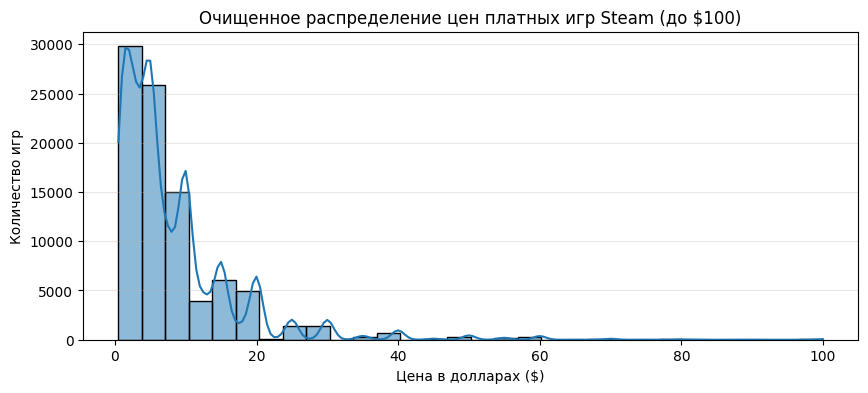

In [194]:
paid_usd = (
    apps_clean
    .filter((pl.col('is_free') == False) & (pl.col('final_price') <= 10000))
    .select((pl.col('final_price') / 100.0).alias('price_usd'))
    .to_pandas()
)

plt.figure(figsize=(10, 4))
sns.histplot(paid_usd['price_usd'], bins=30, kde=True)
plt.title('Очищенное распределение цен платных игр Steam (до $100)')
plt.xlabel('Цена в долларах ($)')
plt.ylabel('Количество игр')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Оптимизация типов и переименование колонок
Приводим числовые столбцы к целочисленным типам (`Int32`/`Int64`) для экономии памяти в RAM и на диске, а также убираем технические префиксы `mat_` у материализованных признаков.

In [198]:
apps_final = (
    apps_clean
    .with_columns(
        pl.col('recommendations_total').cast(pl.Int64),
        pl.col('mat_achievement_count').cast(pl.Int32),
        pl.col('metacritic_score').cast(pl.Int32),
        pl.col('initial_price').cast(pl.Int64),
        pl.col('final_price').cast(pl.Int64)
    )
    .drop(['mat_initial_price', 'mat_final_price'])
    .rename({
        'mat_achievement_count': 'achievement_count',
        'mat_discount_percent': 'discount_percent',
        'mat_supports_windows': 'supports_windows',
        'mat_supports_mac': 'supports_mac',
        'mat_supports_linux': 'supports_linux'
    })
)

apps_final.head(3)

appid,name,type,is_free,metacritic_score,recommendations_total,achievement_count,mat_currency,discount_percent,supports_windows,supports_mac,supports_linux,genre,category,release_year,combined_text,initial_price,final_price
i64,str,str,bool,i32,i64,i32,str,f64,bool,bool,bool,list[str],list[str],i32,str,i64,i64
10,"""Counter-Strike""","""game""",false,88,161854,0,"""USD""",0.0,true,true,true,"[""action""]","[""color alternatives"", ""pvp"", … ""shared/split screen pvp""]",2000,"""Counter-Strike | Genres: actio…",999,999
20,"""Team Fortress Classic""","""game""",false,0,6633,0,"""USD""",0.0,true,true,true,"[""action""]","[""pvp"", ""family sharing"", … ""shared/split screen pvp""]",1999,"""Team Fortress Classic | Genres…",499,499
30,"""Day of Defeat""","""game""",false,79,4308,0,"""USD""",0.0,true,true,true,"[""action""]","[""color alternatives"", ""family sharing"", … ""valve anti-cheat enabled""]",2003,"""Day of Defeat | Genres: action…",499,499


### Сохранение очищенного датасета метаданных игр
Сохраняем итоговую витрину метаданных игр в формат Parquet (`games_clean.parquet`) для эффективной последующей загрузки.

In [ ]:
os.makedirs(output_dir, exist_ok=True)
apps_final.write_parquet(os.path.join(output_dir, 'games_clean.parquet'))
print(f"Обработка игр завершена. Сохранено строк: {apps_final.height}, колонок: {apps_final.width}")